<div style="background-color: #f5f5f5; border: 2px solid black; border-radius: 10px; padding: 30px 20px; margin: 10px 0px; text-align: center;">
    
<h1 style="margin: 0px 0px 10px 0px;"> Rain gauge optimisation in the Upper Severn </h1>

<div style="text-align: left; margin-top: 20px;">
    

---   

**AIM:** Identify locations for installation of new rain gauges in the Upper Severn catchment. The rain gauge locations should sample a range of topographic conditions, while also ensuring that each gauge sits in a location whose fine-scale terrain is representative of the coarser 1km cell it occupies. This should mean that radar-gauge comparisons at 1km resolution aren't distorted by the gauge sampling an atypical microsite within its cell.    
    
The methodology has the following steps:

    
1. Cluster analysis at two resolutions
Run k-means clustering on elevation and slope independently at 30m (native DEM resolution) and at 1km (grid-cell means), producing two separate cluster typologies of the catchment's terrain.

2. Compute 30m purity per 1km cell
For each 1km grid cell, calculate the proportion of its constituent 30m cells that belong to the same (dominant) 30m cluster. This gives a "purity" score per 1km cell — a measure of how internally homogeneous its terrain is at fine resolution.

3. Select new gauge locations
For each 1km-resolution cluster, ensure it contains 2 gauges in total (existing + new). New gauges should be placed within 1km cells that:
    - belong to the target 1km cluster, and
    - have high 30m purity (i.e. the cell is a genuinely representative, internally consistent sample of that terrain type, not  a diluted mix), and
    - maintain a minimum spacing from all other gauge locations (existing and newly proposed).  

    
4. Select the exact 30m location within the chosen 1km cell
Within each selected 1km grid cell, choose the specific 30m cell whose elevation and slope values are closest to the mean elevation/slope of that 1km cell.

    
---

</div>

In [22]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import importlib
import matplotlib.colors as mcolors
import matplotlib
from matplotlib.patches import Patch
import random
import rioxarray
import rasterio
from rasterio.features import rasterize
from rasterio.mask import mask
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist
from matplotlib.lines import Line2D
from IPython.display import display

data_dir = "/scratch/hydro4/users/kv25483/FDRI/Rain_gauge_optimisation/Data/"
catchment_Dolwen = gpd.read_file(data_dir + "54080/54080.shp")

import functions
importlib.reload(functions)
from functions import *   # expects: is_feasible, greedy_selection_multi (or greedy_selection), score

def greedy_selection_multi(cluster_candidates, cluster_counts, cell_coords, existing_coords, min_dist):
    selected = {c: [] for c in cluster_candidates}
    selected_idx = []
    failed_clusters = {}
    for cluster_id, candidates in cluster_candidates.items():
        n_needed = int(cluster_counts.get(cluster_id, 0))
        count = 0
        for idx in candidates:
            if count >= n_needed:
                break
            candidate_xy = cell_coords[idx]
            if is_feasible(candidate_xy, selected_idx, cell_coords, existing_coords, min_dist):
                selected[cluster_id].append(idx)
                selected_idx.append(idx)
                count += 1
        if count < n_needed:
            failed_clusters[cluster_id] = f"only placed {count}/{n_needed}"
    return selected, failed_clusters

In [2]:
landcover_path = data_dir + "lmc2023 clip.tif"

src = rasterio.open(landcover_path)
landcover = src.read(1)  # read first band

# Ensure CRS matches
catchment_Dolwen = catchment_Dolwen.to_crs(src.crs)

# Convert geometry to GeoJSON-like format
geoms = catchment_Dolwen.geometry.values

clipped, transform = mask(src, geoms, crop=True)
clipped = clipped[0]  # first band

# Mask zeros
clipped_masked = np.ma.masked_where(clipped == 0, clipped);

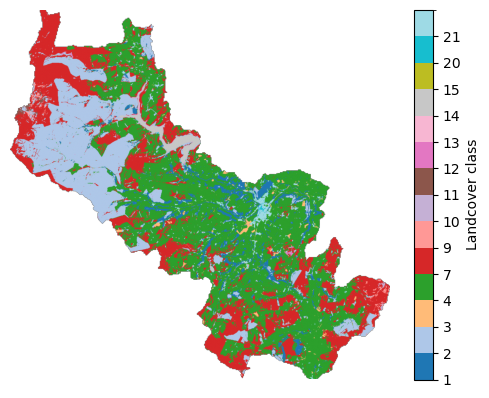

In [3]:
classes = np.unique(landcover)
classes = classes[classes != 0]  # optional: drop 0 if it's background

cmap = plt.get_cmap("tab20", len(classes))

norm = mcolors.BoundaryNorm( boundaries=np.append(classes, classes[-1] + 1), ncolors=len(classes))

landcover_masked = np.ma.masked_where(landcover == 0, landcover)

cmap = cmap.copy()
cmap.set_bad(color="none")

plt.imshow(landcover_masked, cmap=cmap, norm=norm)

cbar = plt.colorbar(ticks=classes)
cbar.set_label("Landcover class")

plt.axis("off");

In [4]:
# --------------------------------------------------
# Load dataset containing locations of existing gauges +
# --------------------------------------------------
rain_meta_cmd = pd.read_csv(data_dir + "rain_meta_for_CMD.csv")
rain_meta_sf = gpd.GeoDataFrame(
    rain_meta_cmd,
    geometry=gpd.points_from_xy(rain_meta_cmd["x_2"], rain_meta_cmd["y_2"]),
    crs="EPSG:27700")

rainfall_gdf_merged = gpd.read_file(data_dir + "Derived/rainfall_gdf_merged.gpkg")

<div style="background-color: lightblue; border: 2px solid black; border-radius: 10px; padding: 30px 20px; margin: 10px 0px; text-align: center;">
    
<div style="text-align: left; margin-top: 20px;">
    

--- 
1. Run cluster analysis at 2 resolutions to produce two separate cluster typologies: 30m (native resolution) and 1km resolution

---

</div>

## 1km

In [5]:
# Decide features to cluster on
feature_cols = ["mean_dem", "mean_slope"]

# Remove rows with NA values
valid_mask_1km = rainfall_gdf_merged[feature_cols].notna().all(axis=1)
rainfall_gdf_valid = rainfall_gdf_merged.loc[valid_mask_1km].reset_index(drop=True)

# Get the feature columns and appply a scaler
features_1km = rainfall_gdf_valid[feature_cols]
scaler_1km = StandardScaler()
X_1km = scaler_1km.fit_transform(features_1km)

# Apply kmeans clustering
k = 5
kmeans_1km = KMeans(n_clusters=k, random_state=0)
labels_1km = kmeans_1km.fit_predict(X_1km)

# Apply cluster labels back to dataframe
rainfall_gdf_valid["cluster"] = labels_1km
rainfall_gdf_valid["zone_id"] = np.arange(len(rainfall_gdf_valid))

## 30m

In [6]:
# Get 30m elevation data
dem_path = data_dir + "dem_Dolwen.tif"
with rioxarray.open_rasterio(dem_path, masked=True) as dem_rx:
    dem = dem_rx.squeeze()
    dem_arr = dem.values.astype(float)
    transform = dem.rio.transform()

# Create 30m slope data
dx = transform.a
dy = -transform.e
dz_dy, dz_dx = np.gradient(dem_arr, dy, dx)
slope_arr = np.degrees(np.arctan(np.sqrt(dz_dx**2 + dz_dy**2)))

# Mask out columns with NAN values
valid_mask_30m = ~np.isnan(dem_arr) & ~np.isnan(slope_arr)
features_30m = np.column_stack([dem_arr[valid_mask_30m], slope_arr[valid_mask_30m]])

# Scale the features
scaler_30m = StandardScaler()
X_30m = scaler_30m.fit_transform(features_30m)

# Run kmeans clustering
k_30m = 5
kmeans_30m = KMeans(n_clusters=k_30m, random_state=0)
labels_30m = kmeans_30m.fit_predict(X_30m)

# Place 30m labels back into full 2D grid shape
labels_30m_full = np.full(dem_arr.shape, -1, dtype=int)
labels_30m_full[valid_mask_30m] = labels_30m

<div style="background-color: lightblue; border: 2px solid black; border-radius: 10px; padding: 30px 20px; margin: 10px 0px; text-align: center;">
    
<div style="text-align: left; margin-top: 20px;">
    

--- 
2. Compute 30m purity per 1km grid cell

---

</div>

In [7]:
# Rasterize 1km cells onto the 30m DEM grid (i.e. convert from vector polygons to a raster layer) 
# so every 30m pixel knows which 1km cell (zone_id) it falls inside
zone_raster = rasterize([(geom, zid) for geom, zid in zip(rainfall_gdf_valid.geometry, rainfall_gdf_valid["zone_id"])],
    out_shape=dem_arr.shape, transform=transform, fill=-1, dtype="int32")

# Combine zone_id + 30m cluster label for every valid 30m pixel
combined_mask = valid_mask_30m & (zone_raster >= 0)

# For every valid 30m pixel create a row in a dataframe with the zone ID and the 30m cluster label
pixel_df = pd.DataFrame({"zone_id": zone_raster[combined_mask],"cluster_30m": labels_30m_full[combined_mask],})

# Find the count/proportion of each cluster label in each zone
counts = pixel_df.groupby(["zone_id", "cluster_30m"]).size().unstack(fill_value=0)
proportions = counts.div(counts.sum(axis=1), axis=0)

# Find the maximum proportion across the clusters, and what the dominant 30m cluster is
purity = proportions.max(axis=1)
dominant_30m_cluster = proportions.idxmax(axis=1)

# Add to dataframe of rainfall data
rainfall_gdf_valid["purity"] = rainfall_gdf_valid["zone_id"].map(purity)
rainfall_gdf_valid["dominant_30m_cluster"] = rainfall_gdf_valid["zone_id"].map(dominant_30m_cluster)

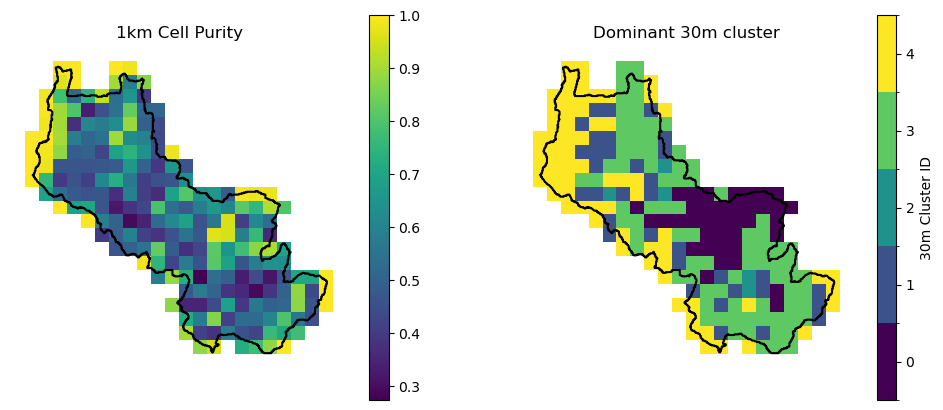

In [8]:
fig, axs = plt.subplots(ncols = 2, figsize=(12, 5))

rainfall_gdf_valid.plot(column="purity", cmap="viridis", legend=True, ax=axs[0])

catchment_Dolwen.boundary.plot(ax=axs[0], color="black")
axs[0].set_title("1km Cell Purity")
axs[0].axis("off");

# Define discrete colormap (5 clusters → 5 colours)
cmap = plt.get_cmap("viridis", 5)

# Define boundaries so each integer gets its own colour bin
bounds = np.arange(-0.5, 5.5, 1)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Plot
rainfall_gdf_valid.plot(column="dominant_30m_cluster",cmap=cmap,norm=norm,legend=False,ax=axs[1])

catchment_Dolwen.boundary.plot(ax=axs[1], color="black")
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []

cbar = plt.colorbar(sm, ax=axs[1], boundaries=bounds, ticks=range(5))
cbar.set_label("30m Cluster ID")

axs[1].set_title("Dominant 30m cluster")
axs[1].axis("off"); 

In [9]:
# plt.hist(rainfall_gdf_valid["purity"], bins=30)
# plt.axvline(0.7, color="red", linestyle="--")
# plt.title("Distribution of cell homogeneity");

<div style="background-color: lightblue; border: 2px solid black; border-radius: 10px; padding: 30px 20px; margin: 10px 0px; text-align: center;">
    
<div style="text-align: left; margin-top: 20px;">
    
--- 
3. Select new gauge locations

---    
    
For each 1km-resolution cluster, ensure it contains 2 gauges in total (existing + new). New gauges should be placed within 1km cells that:

- Belong to the target 1km cluster, and
- Have high 30m purity (i.e. the cell is a genuinely representative, internally consistent sample of that terrain type, not a diluted mix), and
- Maintain a minimum spacing from all other gauge locations (existing and newly proposed).
    

</div>

---

###  Assign existing gauges to 1km cells + clusters

---

In [10]:
gauge_with_cells = gpd.sjoin(rain_meta_sf,
                             rainfall_gdf_valid[["geometry", "cluster", "purity", "zone_id", "mean_dem", "mean_slope"]],
    how="inner",predicate="within").reset_index(drop=True)

existing_counts = gauge_with_cells["cluster"].value_counts().reindex(range(k), fill_value=0)

---

### Find the number of new gauges needed in each cluster.

This is based on an assumption of each cluster having the same number of gauges. 

Alternatives:  
- Proportional assignment to clusters based on coverage of the catchment  
- Relevance of clusters to rainfall-runoff relationships?

---

In [11]:
# Define how many new gauges are needed in each cluster
n_existing = 8
n_total_final = 18
n_new = n_total_final - n_existing
target_quota = pd.Series(n_total_final / k, index=range(k))

# Only existing gauges sitting in high-purity cells count toward "fulfilling" a cluster's quota.
# Low-purity existing gauges still exist (and still take up space for min_dist purposes later),
# but don't reduce how many well-placed gauges the cluster still needs
purity_threshold = 0.6
gauge_with_cells["well_covered"] = gauge_with_cells["purity"] >= purity_threshold
effective_existing_counts = (gauge_with_cells[gauge_with_cells["well_covered"]]["cluster"]
    .value_counts()
    .reindex(range(k), fill_value=0))

# Define how many new gauges are needed (accounting for existing ones which don't meet purity threshold)
new_needed = pd.Series(0, index=range(k))
for _ in range(n_new):
    current_total = effective_existing_counts + new_needed
    gap = target_quota - current_total
    target_cluster = gap.idxmax()
    new_needed[target_cluster] += 1

# Create summary table
summary = pd.DataFrame({ "target_quota": target_quota.round(2),
    "all_existing": gauge_with_cells["cluster"].value_counts().reindex(range(k), fill_value=0),
    "high_purity_existing": effective_existing_counts, "new_needed": new_needed,})

summary.index.name = "cluster"
summary.loc["TOTAL"] = summary.sum()
summary = summary.astype({"all_existing": int, "high_purity_existing": int, "new_needed": int})
assert new_needed.sum() == n_new
display(summary)

,target_quota,all_existing,high_purity_existing,new_needed
cluster,,,,
0,3.6,2,1,2
1,3.6,2,0,3
2,3.6,0,0,3
3,3.6,2,2,1
4,3.6,2,2,1
TOTAL,18.0,8,5,10


---

### Find the 1km cells in which to place the new gauges

This involves ranking 1km cells within each cluster by purity, then greedily selecting enough cells per cluster (respecting min_dist) to meet quota

---

In [12]:
min_dist = 3000  # metres

# Get the coordinates of the existing gauges
existing_coords = np.column_stack([gauge_with_cells.geometry.x.values, gauge_with_cells.geometry.y.values])

# Get the centroid coordinates of the 1km cells
#     for the min_dist spacing check between candidate CELLS (coarse check) — fine-grained 30m check happens after
cell_centroids = np.column_stack([rainfall_gdf_valid.geometry.centroid.x.values, rainfall_gdf_valid.geometry.centroid.y.values])

# Greedily select new gauge locations within each cluster, prioritising
# high-purity 1km cells, subject to a minimum-distance feasibility
# constraint against both the existing network and gauges already
# selected in this pass (including from other clusters).

selected_zone_ids_per_cluster = {c: [] for c in range(k)}
all_selected_idx = []   # indices into rainfall_gdf_valid, across all clusters
                         # (shared/running list so gauges from different
                         # clusters can't end up too close to each other)

for cluster_id in range(k):
    n_needed = int(new_needed[cluster_id])
    if n_needed == 0:
        continue

    # Candidate cells belonging to this cluster only
    cluster_cells = rainfall_gdf_valid[rainfall_gdf_valid["cluster"] == cluster_id]

    # Rank candidates by purity, most homogeneous first -- these are
    # tried before less "pure" cells
    ranked_idx = cluster_cells.sort_values("purity", ascending=False).index.tolist()

    count = 0
    for idx in ranked_idx:
        if count >= n_needed:
            break  # this cluster's quota is filled

        candidate_xy = cell_centroids[idx]

        # Feasibility = respects min_dist from existing gauges AND from
        # every gauge selected so far in this run (all clusters combined)
        if is_feasible(candidate_xy, all_selected_idx, cell_centroids, existing_coords, min_dist):
            selected_zone_ids_per_cluster[cluster_id].append(idx)
            all_selected_idx.append(idx)
            count += 1
        # else: candidate rejected for spacing, move to next-best-purity cell
        # NOTE: no backtracking -- an early greedy pick can block a better
        # later configuration; this is a single deterministic pass

    if count < n_needed:
        # Ran out of ranked candidates before hitting quota, almost always
        # because remaining high-purity cells were too close to something
        # already chosen
        print(f"Cluster {cluster_id}: only found {count}/{n_needed} feasible high-purity cells")


<div style="background-color: lightblue; border: 2px solid black; border-radius: 10px; padding: 30px 20px; margin: 10px 0px; text-align: center;">
    
<div style="text-align: left; margin-top: 20px;">
    
--- 
4. Select the exact 30m location within the chosen 1km cell
---    
    
Within each selected 1km grid cell, choose the specific 30m cell whose elevation and slope values are closest to the mean elevation/slope of that 1km cell.
</div>

In [63]:
from rasterio.features import rasterize
from scipy.ndimage import distance_transform_edt, binary_fill_holes

min_dist = 2500
min_dist_to_boundary = 500  # e.g. keep gauges at least 500m inside the catchment edge

# --- Rasterize the catchment polygon onto the same grid as dem_arr ---
# Dissolve first in case catchment_Dolwen has multiple rows/parts that
# should be treated as one catchment boundary
catchment_geom = catchment_Dolwen.geometry.union_all() if hasattr(catchment_Dolwen.geometry, "union_all") \
    else catchment_Dolwen.unary_union  # unary_union is the older geopandas/shapely API; union_all is newer

catchment_mask = rasterize(
    [(catchment_geom, 1)],
    out_shape=dem_arr.shape,
    transform=transform,
    fill=0,
    dtype="uint8",
).astype(bool)

# Fill any internal holes (e.g. nodata gaps, small excluded polygons within
# the catchment) so distance-to-boundary reflects the true outer edge only,
# not internal gaps
catchment_mask_filled = binary_fill_holes(catchment_mask)

# --- Precompute distance-to-boundary for every pixel, once, outside the loop ---
pixel_size = transform.a  # assumes square pixels
dist_to_boundary_px = distance_transform_edt(catchment_mask_filled)
dist_to_boundary_m = dist_to_boundary_px * pixel_size

# Create list to store results
selected_records = []
diagnostics = {}   # zone_id -> dict with ranked candidates + cluster distribution, for inspection/plotting

# Running list of (x, y) coords for every gauge already committed to --
# starts with the existing network, and grows as each new gauge is placed,
# so later zones in the loop are checked against earlier ones too
all_selected_coords_so_far = np.array(
    existing_coords.tolist() if hasattr(existing_coords, "tolist") else list(existing_coords)
)

# For each 1km zone selected in the previous step, drop down to the 30m
# pixel level and pick the single best 30m pixel within that zone to put the gauge in
for cluster_id, idx_list in selected_zone_ids_per_cluster.items():
    for idx in idx_list:
        row = rainfall_gdf_valid.iloc[idx]
        zone_id = row["zone_id"]

        target_dem = row["mean_dem"]
        target_slope = row["mean_slope"]

        cell_pixel_mask = combined_mask & (zone_raster == zone_id)
        cand_rows, cand_cols = np.where(cell_pixel_mask)

        cand_dem = dem_arr[cand_rows, cand_cols]
        cand_slope = slope_arr[cand_rows, cand_cols]
        cand_cluster_30m = labels_30m_full[cand_rows, cand_cols]

        dem_std = np.nanstd(dem_arr[valid_mask_30m])
        slope_std = np.nanstd(slope_arr[valid_mask_30m])

        dist_to_target = np.sqrt(((cand_dem - target_dem) / dem_std) ** 2 + ((cand_slope - target_slope) / slope_std) ** 2)

        order = np.argsort(dist_to_target)
        candidates_ranked = pd.DataFrame({
            "row": cand_rows[order], "col": cand_cols[order], "dem": cand_dem[order],
            "slope": cand_slope[order], "cluster_30m": cand_cluster_30m[order], "dist_to_target": dist_to_target[order],
        })

        # Real-world coords for every candidate pixel
        cand_x, cand_y = rasterio.transform.xy(transform, candidates_ranked["row"].values, candidates_ranked["col"].values)
        candidates_ranked["x"] = cand_x
        candidates_ranked["y"] = cand_y

        # Distance to catchment boundary, looked up directly from the precomputed array
        candidates_ranked["dist_to_boundary"] = dist_to_boundary_m[
            candidates_ranked["row"].values, candidates_ranked["col"].values
        ]

        # Feasibility against every gauge committed to so far (existing + already-placed new gauges)
        if len(all_selected_coords_so_far):
            d = np.sqrt(
                ((candidates_ranked["x"].values[:, None] - all_selected_coords_so_far[None, :, 0]) ** 2) +
                ((candidates_ranked["y"].values[:, None] - all_selected_coords_so_far[None, :, 1]) ** 2)
            )
            feasible_dist = d.min(axis=1) >= min_dist
        else:
            feasible_dist = np.ones(len(candidates_ranked), dtype=bool)

        feasible_boundary = candidates_ranked["dist_to_boundary"].values >= min_dist_to_boundary

        # Keep both flags separately so we can diagnose *why* a zone fails, not just *that* it fails
        candidates_ranked["feasible_spacing"] = feasible_dist
        candidates_ranked["feasible_boundary"] = feasible_boundary
        candidates_ranked["feasible"] = feasible_dist & feasible_boundary

        feasible_candidates = candidates_ranked[candidates_ranked["feasible"]]

        if len(feasible_candidates):
            best = feasible_candidates.iloc[0]
        else:
            # No 30m pixel in this zone satisfies both constraints -- fall back to the
            # most representative pixel anyway, but flag it and report which
            # constraint(s) were the actual blocker across the candidate pool
            best = candidates_ranked.iloc[0]
            n_fail_spacing = (~candidates_ranked["feasible_spacing"]).sum()
            n_fail_boundary = (~candidates_ranked["feasible_boundary"]).sum()
            print(f"Zone {zone_id}: NO feasible 30m pixel found "
                  f"(min_dist={min_dist}m, min_dist_to_boundary={min_dist_to_boundary}m) -- "
                  f"{n_fail_spacing}/{len(candidates_ranked)} failed spacing, "
                  f"{n_fail_boundary}/{len(candidates_ranked)} failed boundary -- "
                  f"falling back to top dist_to_target pick, flagged infeasible")

        diagnostics[zone_id] = {
            "candidates_ranked": candidates_ranked,
            "cluster_distribution": pd.Series(cand_cluster_30m).value_counts(normalize=True).sort_index(),
            "target_dem": target_dem, "target_slope": target_slope,
        }

        x, y = rasterio.transform.xy(transform, int(best["row"]), int(best["col"]))

        selected_records.append({
            "cluster": cluster_id, "zone_id": zone_id,
            "row": int(best["row"]), "col": int(best["col"]), "x": x, "y": y,
            "dem": best["dem"], "slope": best["slope"],
            "cell_purity": row["purity"],
            "feasible": bool(best["feasible"]),
            "feasible_spacing": bool(best["feasible_spacing"]),
            "feasible_boundary": bool(best["feasible_boundary"]),
            "dist_to_boundary": best["dist_to_boundary"],
        })

        # Add this gauge's real position to the running list so subsequent
        # zones are checked against it too
        all_selected_coords_so_far = np.vstack([all_selected_coords_so_far, [[x, y]]])

selected_df = pd.DataFrame(selected_records)
selected_df['new_gauge_num'] = range(1, len(selected_df) + 1)

from IPython.display import display
display(selected_df)

# Quick summary of how many zones had to fall back to an infeasible pixel,
# broken down by which constraint(s) were binding
n_infeasible = (~selected_df["feasible"]).sum()
if n_infeasible:
    print(f"\n{n_infeasible} zone(s) had no feasible 30m pixel and fell back to an infeasible pick:")
    display(selected_df[~selected_df["feasible"]][
        ["zone_id", "cluster", "row", "col", "cell_purity", "feasible_spacing", "feasible_boundary", "dist_to_boundary"]
    ])

Zone 128: NO feasible 30m pixel found (min_dist=2500m, min_dist_to_boundary=500m) -- 2437/2437 failed spacing, 2437/2437 failed boundary -- falling back to top dist_to_target pick, flagged infeasible
Zone 60: NO feasible 30m pixel found (min_dist=2500m, min_dist_to_boundary=500m) -- 0/9667 failed spacing, 9667/9667 failed boundary -- falling back to top dist_to_target pick, flagged infeasible
Zone 83: NO feasible 30m pixel found (min_dist=2500m, min_dist_to_boundary=500m) -- 0/6580 failed spacing, 6580/6580 failed boundary -- falling back to top dist_to_target pick, flagged infeasible


,cluster,zone_id,row,col,x,y,dem,slope,cell_purity,feasible,feasible_spacing,feasible_boundary,dist_to_boundary,new_gauge_num
0,0,143,1893,3094,296997.500031,286107.499884,183.029999,8.878083,0.989933,True,True,True,501.522681,1
1,0,128,2002,3512,299087.500030,285562.499884,177.100006,10.692143,0.799754,False,False,False,35.355339,2
2,1,192,723,437,283712.500035,291957.499882,477.250000,9.146919,0.898950,True,True,True,801.451807,3
3,1,87,2514,1483,288942.500033,283002.499885,357.820007,9.592897,0.591850,True,True,True,838.629835,4
4,1,220,311,1436,288707.500033,294017.499882,340.980011,9.023586,0.583026,True,True,True,514.781507,5
5,2,52,2983,2551,294282.500032,280657.499886,340.299988,13.286215,0.532900,True,True,True,1589.536095,6
6,2,76,2681,1956,291307.500033,282167.499885,371.100006,13.865969,0.482325,True,True,True,1145.000000,7
7,2,134,1896,1220,287627.500034,286092.499884,366.179993,18.500641,0.373125,True,True,True,1986.183526,8
8,3,60,3035,4123,302142.500029,280397.499886,535.700012,5.223186,0.998138,False,True,False,90.138782,9
9,4,83,2546,3341,298232.500031,282842.499885,333.160004,5.743332,0.911094,False,True,False,118.004237,10



3 zone(s) had no feasible 30m pixel and fell back to an infeasible pick:


,zone_id,cluster,row,col,cell_purity,feasible_spacing,feasible_boundary,dist_to_boundary
1,128,0,2002,3512,0.799754,False,False,35.355339
8,60,3,3035,4123,0.998138,True,False,90.138782
9,83,4,2546,3341,0.911094,True,False,118.004237


In [ ]:
from scipy.ndimage import distance_transform_edt

min_dist = 2500
min_dist_to_boundary = 500  # e.g. keep gauges at least 500m inside the catchment edge

# --- Precompute distance-to-boundary for every pixel, once, outside the loop ---
# `catchment_mask` should be a boolean array, True = inside the catchment,
# same shape as dem_arr/slope_arr etc. If you don't already have this
# separately from combined_mask, let me know how the catchment boundary is
# stored (geopandas polygon vs raster) and I can adjust.
pixel_size = transform.a  # assumes square pixels, e.g. 30 for 30m rasters
dist_to_boundary_px = distance_transform_edt(catchment_mask)
dist_to_boundary_m = dist_to_boundary_px * pixel_size

# Create list to store results
selected_records = []
diagnostics = {}   # zone_id -> dict with ranked candidates + cluster distribution, for inspection/plotting

# Running list of (x, y) coords for every gauge already committed to --
# starts with the existing network, and grows as each new gauge is placed,
# so later zones in the loop are checked against earlier ones too
all_selected_coords_so_far = np.array(
    existing_coords.tolist() if hasattr(existing_coords, "tolist") else list(existing_coords))

# For each 1km zone selected in the previous step, drop down to the 30m
# pixel level and pick the single best 30m pixel within that zone to put the gauge in
for cluster_id, idx_list in selected_zone_ids_per_cluster.items():
    for idx in idx_list:
        row = rainfall_gdf_valid.iloc[idx]
        zone_id = row["zone_id"]

        target_dem = row["mean_dem"]
        target_slope = row["mean_slope"]

        cell_pixel_mask = combined_mask & (zone_raster == zone_id)
        cand_rows, cand_cols = np.where(cell_pixel_mask)

        cand_dem = dem_arr[cand_rows, cand_cols]
        cand_slope = slope_arr[cand_rows, cand_cols]
        cand_cluster_30m = labels_30m_full[cand_rows, cand_cols]

        dem_std = np.nanstd(dem_arr[valid_mask_30m])
        slope_std = np.nanstd(slope_arr[valid_mask_30m])

        dist_to_target = np.sqrt(((cand_dem - target_dem) / dem_std) ** 2 + ((cand_slope - target_slope) / slope_std) ** 2)

        order = np.argsort(dist_to_target)
        candidates_ranked = pd.DataFrame({
            "row": cand_rows[order], "col": cand_cols[order], "dem": cand_dem[order],
            "slope": cand_slope[order], "cluster_30m": cand_cluster_30m[order], "dist_to_target": dist_to_target[order],})

        # Real-world coords for every candidate pixel
        cand_x, cand_y = rasterio.transform.xy(transform, candidates_ranked["row"].values, candidates_ranked["col"].values)
        candidates_ranked["x"] = cand_x
        candidates_ranked["y"] = cand_y

        # Feasibility against every gauge committed to so far (existing + already-placed new gauges)
        if len(all_selected_coords_so_far):
            d = np.sqrt(
                ((candidates_ranked["x"].values[:, None] - all_selected_coords_so_far[None, :, 0]) ** 2) +
                ((candidates_ranked["y"].values[:, None] - all_selected_coords_so_far[None, :, 1]) ** 2))
            candidates_ranked["feasible"] = d.min(axis=1) >= min_dist
        else:
            candidates_ranked["feasible"] = True

        feasible_candidates = candidates_ranked[candidates_ranked["feasible"]]

        if len(feasible_candidates):
            best = feasible_candidates.iloc[0]
        else:
            # No 30m pixel in this zone satisfies min_dist -- fall back to the
            # most representative pixel anyway, but flag it so it doesn't
            # silently violate spacing
            best = candidates_ranked.iloc[0]
            print(f"Zone {zone_id}: NO feasible 30m pixel found (all candidates < {min_dist}m "
                  f"from another gauge) -- falling back to top dist_to_target pick, flagged infeasible")

        diagnostics[zone_id] = {
            "candidates_ranked": candidates_ranked,
            "cluster_distribution": pd.Series(cand_cluster_30m).value_counts(normalize=True).sort_index(),
            "target_dem": target_dem, "target_slope": target_slope,}

        x, y = rasterio.transform.xy(transform, int(best["row"]), int(best["col"]))

        selected_records.append({
            "cluster": cluster_id, "zone_id": zone_id,
            "row": int(best["row"]), "col": int(best["col"]), "x": x, "y": y,
            "dem": best["dem"], "slope": best["slope"],
            "cell_purity": row["purity"],
            "feasible": bool(best["feasible"])})

        # Add this gauge's real position to the running list so subsequent
        # zones are checked against it too
        all_selected_coords_so_far = np.vstack([all_selected_coords_so_far, [[x, y]]])

selected_df = pd.DataFrame(selected_records)
selected_df['new_gauge_num'] = range(1, len(selected_df) + 1)

from IPython.display import display
display(selected_df)

# Quick summary of how many zones had to fall back to an infeasible pixel
n_infeasible = (~selected_df["feasible"]).sum()
if n_infeasible:
    print(f"\n{n_infeasible} zone(s) had no feasible 30m pixel and fell back to an infeasible pick:")
    display(selected_df[~selected_df["feasible"]][["zone_id", "cluster", "row", "col", "cell_purity"]])

In [13]:
min_dist = 2500

# Create list to store results
selected_records = []
diagnostics = {}   # zone_id -> dict with ranked candidates + cluster distribution, for inspection/plotting

# Running list of (x, y) coords for every gauge already committed to --
# starts with the existing network, and grows as each new gauge is placed,
# so later zones in the loop are checked against earlier ones too
all_selected_coords_so_far = np.array(
    existing_coords.tolist() if hasattr(existing_coords, "tolist") else list(existing_coords))

# For each 1km zone selected in the previous step, drop down to the 30m
# pixel level and pick the single best 30m pixel within that zone to put the gauge in
for cluster_id, idx_list in selected_zone_ids_per_cluster.items():
    for idx in idx_list:
        row = rainfall_gdf_valid.iloc[idx]
        zone_id = row["zone_id"]

        target_dem = row["mean_dem"]
        target_slope = row["mean_slope"]

        cell_pixel_mask = combined_mask & (zone_raster == zone_id)
        cand_rows, cand_cols = np.where(cell_pixel_mask)

        cand_dem = dem_arr[cand_rows, cand_cols]
        cand_slope = slope_arr[cand_rows, cand_cols]
        cand_cluster_30m = labels_30m_full[cand_rows, cand_cols]

        dem_std = np.nanstd(dem_arr[valid_mask_30m])
        slope_std = np.nanstd(slope_arr[valid_mask_30m])

        dist_to_target = np.sqrt(((cand_dem - target_dem) / dem_std) ** 2 + ((cand_slope - target_slope) / slope_std) ** 2)

        order = np.argsort(dist_to_target)
        candidates_ranked = pd.DataFrame({
            "row": cand_rows[order], "col": cand_cols[order], "dem": cand_dem[order],
            "slope": cand_slope[order], "cluster_30m": cand_cluster_30m[order], "dist_to_target": dist_to_target[order],})

        # Real-world coords for every candidate pixel
        cand_x, cand_y = rasterio.transform.xy(transform, candidates_ranked["row"].values, candidates_ranked["col"].values)
        candidates_ranked["x"] = cand_x
        candidates_ranked["y"] = cand_y

        # Feasibility against every gauge committed to so far (existing + already-placed new gauges)
        if len(all_selected_coords_so_far):
            d = np.sqrt(
                ((candidates_ranked["x"].values[:, None] - all_selected_coords_so_far[None, :, 0]) ** 2) +
                ((candidates_ranked["y"].values[:, None] - all_selected_coords_so_far[None, :, 1]) ** 2))
            candidates_ranked["feasible"] = d.min(axis=1) >= min_dist
        else:
            candidates_ranked["feasible"] = True

        feasible_candidates = candidates_ranked[candidates_ranked["feasible"]]

        if len(feasible_candidates):
            best = feasible_candidates.iloc[0]
        else:
            # No 30m pixel in this zone satisfies min_dist -- fall back to the
            # most representative pixel anyway, but flag it so it doesn't
            # silently violate spacing
            best = candidates_ranked.iloc[0]
            print(f"Zone {zone_id}: NO feasible 30m pixel found (all candidates < {min_dist}m "
                  f"from another gauge) -- falling back to top dist_to_target pick, flagged infeasible")

        diagnostics[zone_id] = {
            "candidates_ranked": candidates_ranked,
            "cluster_distribution": pd.Series(cand_cluster_30m).value_counts(normalize=True).sort_index(),
            "target_dem": target_dem, "target_slope": target_slope,}

        x, y = rasterio.transform.xy(transform, int(best["row"]), int(best["col"]))

        selected_records.append({
            "cluster": cluster_id, "zone_id": zone_id,
            "row": int(best["row"]), "col": int(best["col"]), "x": x, "y": y,
            "dem": best["dem"], "slope": best["slope"],
            "cell_purity": row["purity"],
            "feasible": bool(best["feasible"])})

        # Add this gauge's real position to the running list so subsequent
        # zones are checked against it too
        all_selected_coords_so_far = np.vstack([all_selected_coords_so_far, [[x, y]]])

selected_df = pd.DataFrame(selected_records)
selected_df['new_gauge_num'] = range(1, len(selected_df) + 1)

from IPython.display import display
display(selected_df)

# Quick summary of how many zones had to fall back to an infeasible pixel
n_infeasible = (~selected_df["feasible"]).sum()
if n_infeasible:
    print(f"\n{n_infeasible} zone(s) had no feasible 30m pixel and fell back to an infeasible pick:")
    display(selected_df[~selected_df["feasible"]][["zone_id", "cluster", "row", "col", "cell_purity"]])

,cluster,zone_id,row,col,x,y,dem,slope,cell_purity,feasible,new_gauge_num
0,0,143,1834,3062,296837.500031,286402.499884,214.479996,8.654608,0.989933,True,1
1,0,128,1984,3539,299222.500030,285652.499884,214.119995,10.896882,0.799754,True,2
2,1,192,723,437,283712.500035,291957.499882,477.250000,9.146919,0.898950,True,3
3,1,87,2514,1483,288942.500033,283002.499885,357.820007,9.592897,0.591850,True,4
4,1,220,184,1329,288172.500034,294652.499882,356.049988,9.473585,0.583026,True,5
5,2,52,2983,2551,294282.500032,280657.499886,340.299988,13.286215,0.532900,True,6
6,2,76,2681,1956,291307.500033,282167.499885,371.100006,13.865969,0.482325,True,7
7,2,134,1896,1220,287627.500034,286092.499884,366.179993,18.500641,0.373125,True,8
8,3,60,3035,4123,302142.500029,280397.499886,535.700012,5.223186,0.998138,True,9
9,4,83,2546,3341,298232.500031,282842.499885,333.160004,5.743332,0.911094,True,10


### Save to file

In [14]:
selected_df[["new_gauge_num", 'x', 'y']].to_csv('Outputs/LocationsForGauges.csv', index=False)

<div style="background-color: lightblue; border: 2px solid black; border-radius: 10px; padding: 30px 20px; margin: 10px 0px; text-align: center;">
    
<div style="text-align: left; margin-top: 20px;">
    
--- 
5. Find backup 30m location within chosen 1km cells
---    
    
Within each selected 1km grid cell, choose 30m cells as backup whose elevation and slope values are next closest to the mean elevation/slope of that 1km cell.
</div>

143


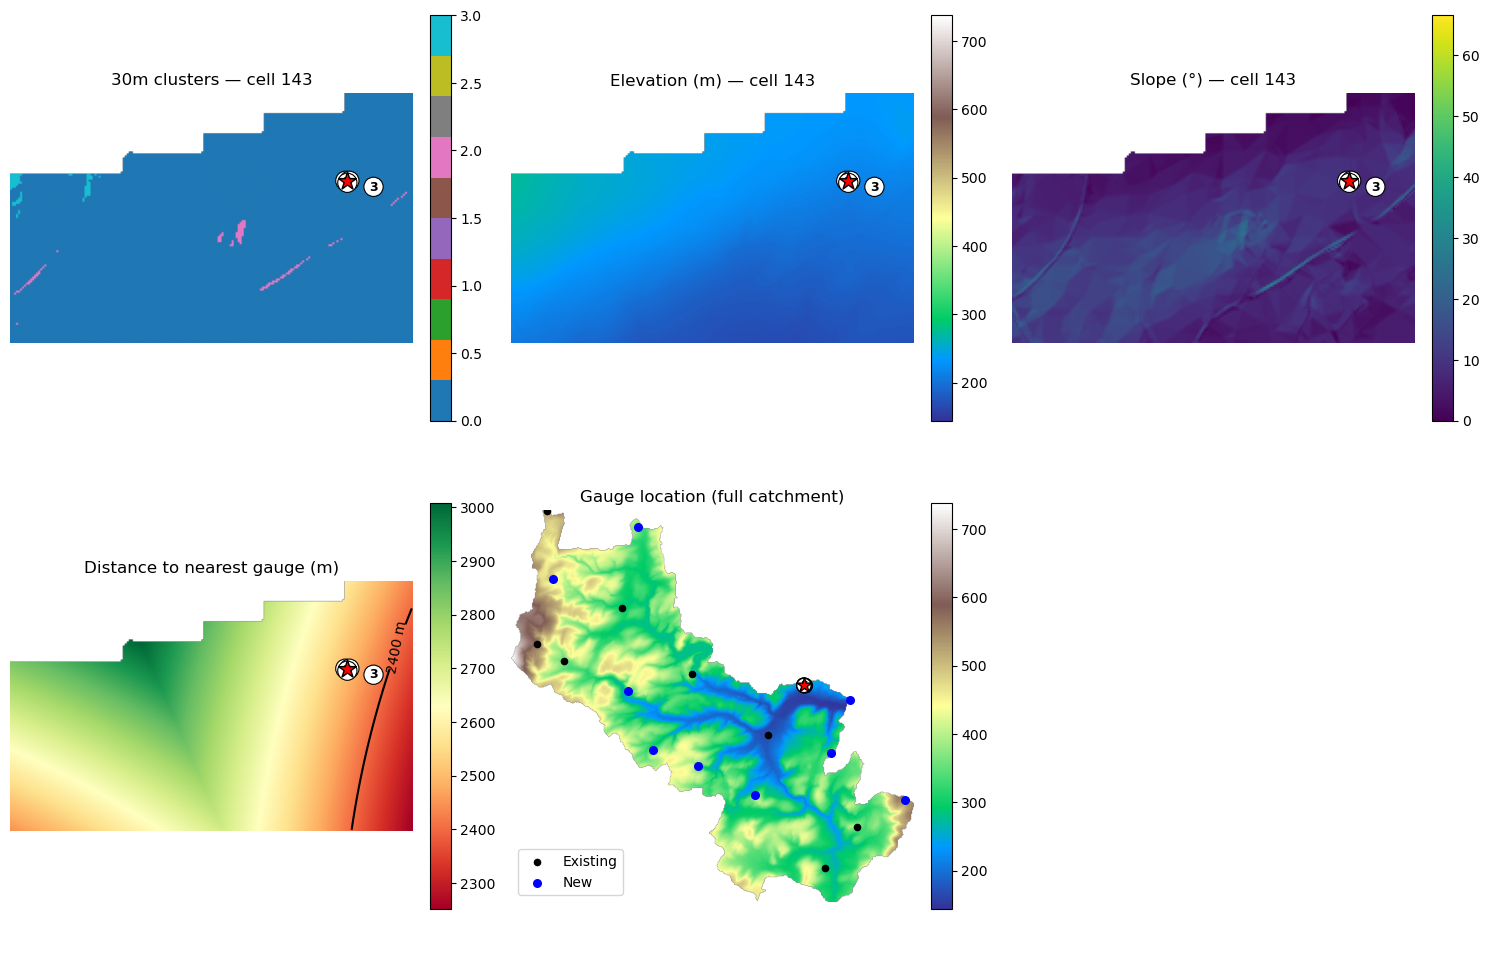

,new_gauge_num,rank,row,col,dem,slope,dist_to_target
0,1,1,1834,3062,214.479996,8.654608,0.002380
1,1,2,1834,3061,214.520004,8.657738,0.002603
2,1,3,1837,3075,213.929993,8.653424,0.004427
3,1,4,1834,3063,214.440002,8.702291,0.005070
4,1,5,1835,3062,213.720001,8.654523,0.006672


128


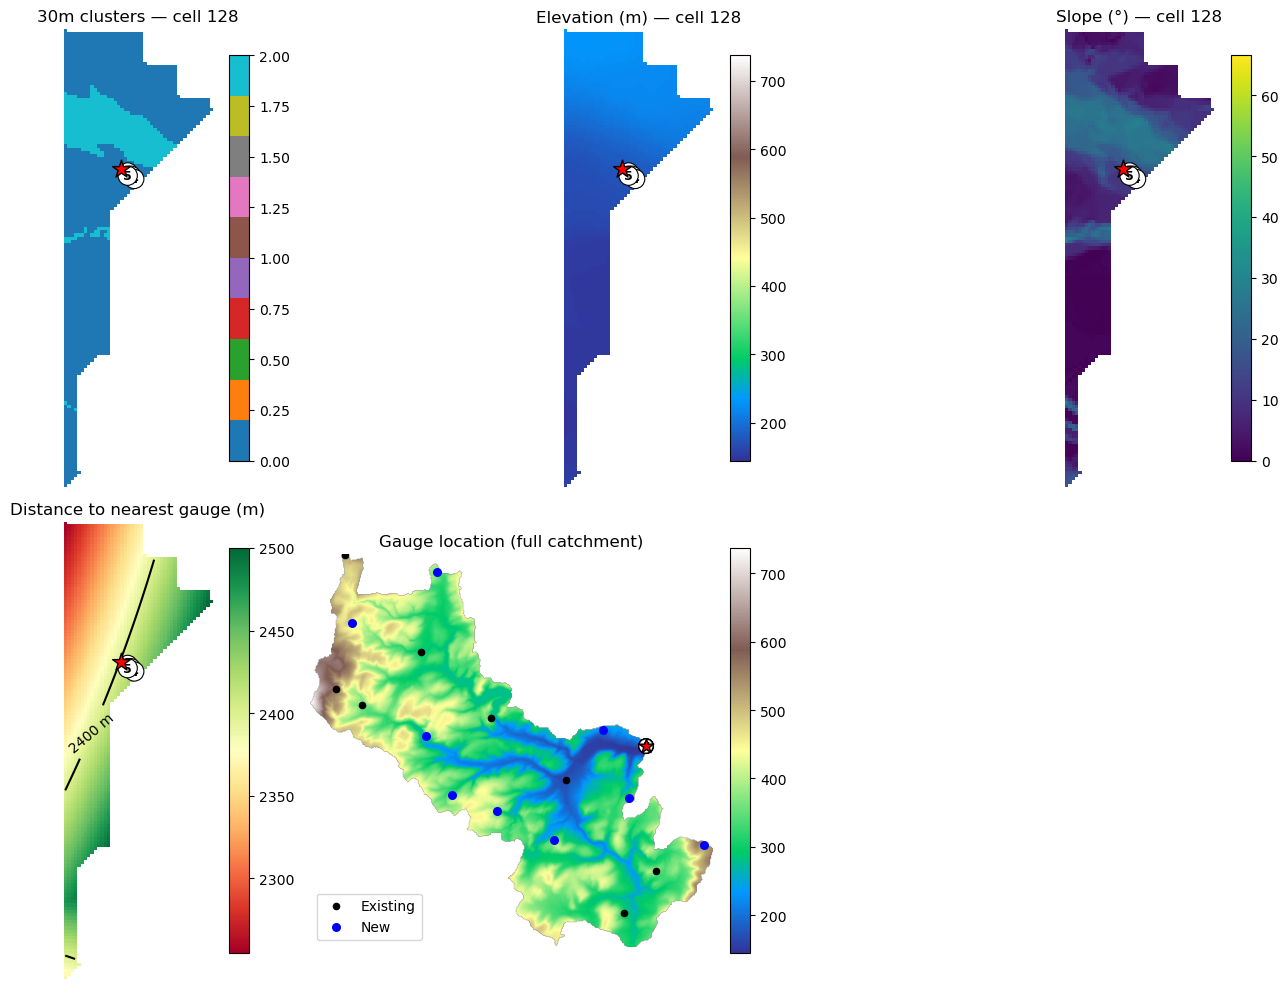

,new_gauge_num,rank,row,col,dem,slope,dist_to_target
0,2,1,2002,3512,177.100006,10.692143,0.108763
1,2,2,2003,3514,176.919998,10.637896,0.112241
2,2,3,2004,3515,176.500000,10.762332,0.114143
3,2,4,2005,3516,176.080002,10.911273,0.118549
4,2,5,2004,3514,176.080002,10.613238,0.122167


192


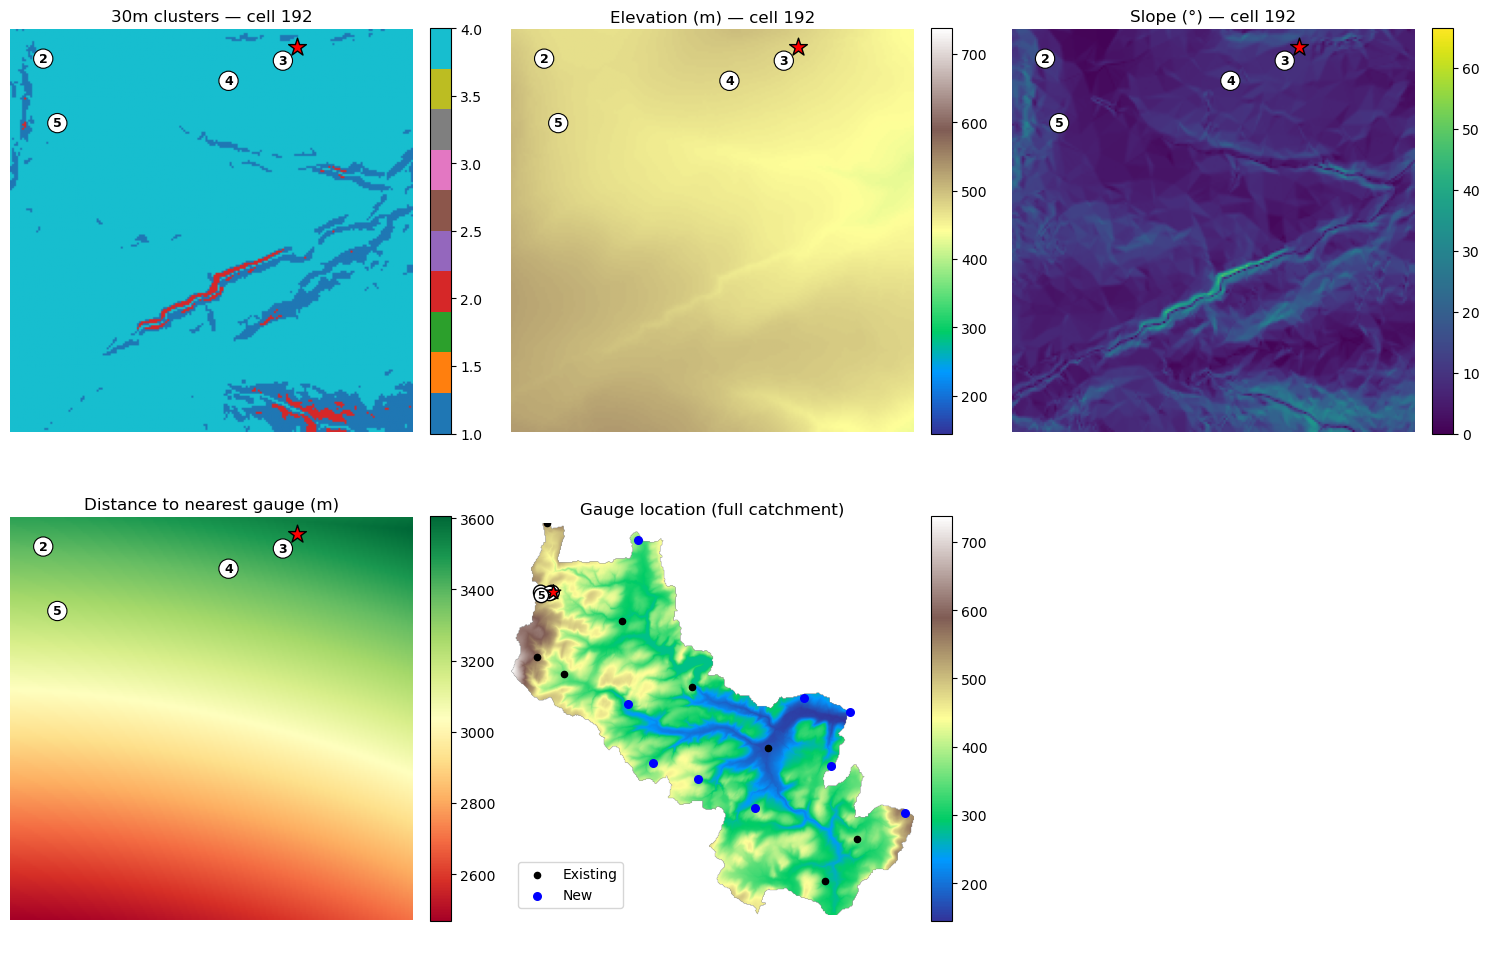

,new_gauge_num,rank,row,col,dem,slope,dist_to_target
0,3,1,723,437,477.250000,9.146919,0.005456
1,3,2,729,311,477.510010,9.154719,0.006632
2,3,3,730,430,476.709991,9.107715,0.007110
3,3,4,740,403,477.010010,9.153104,0.007196
4,3,5,761,318,477.910004,9.134998,0.007437


87


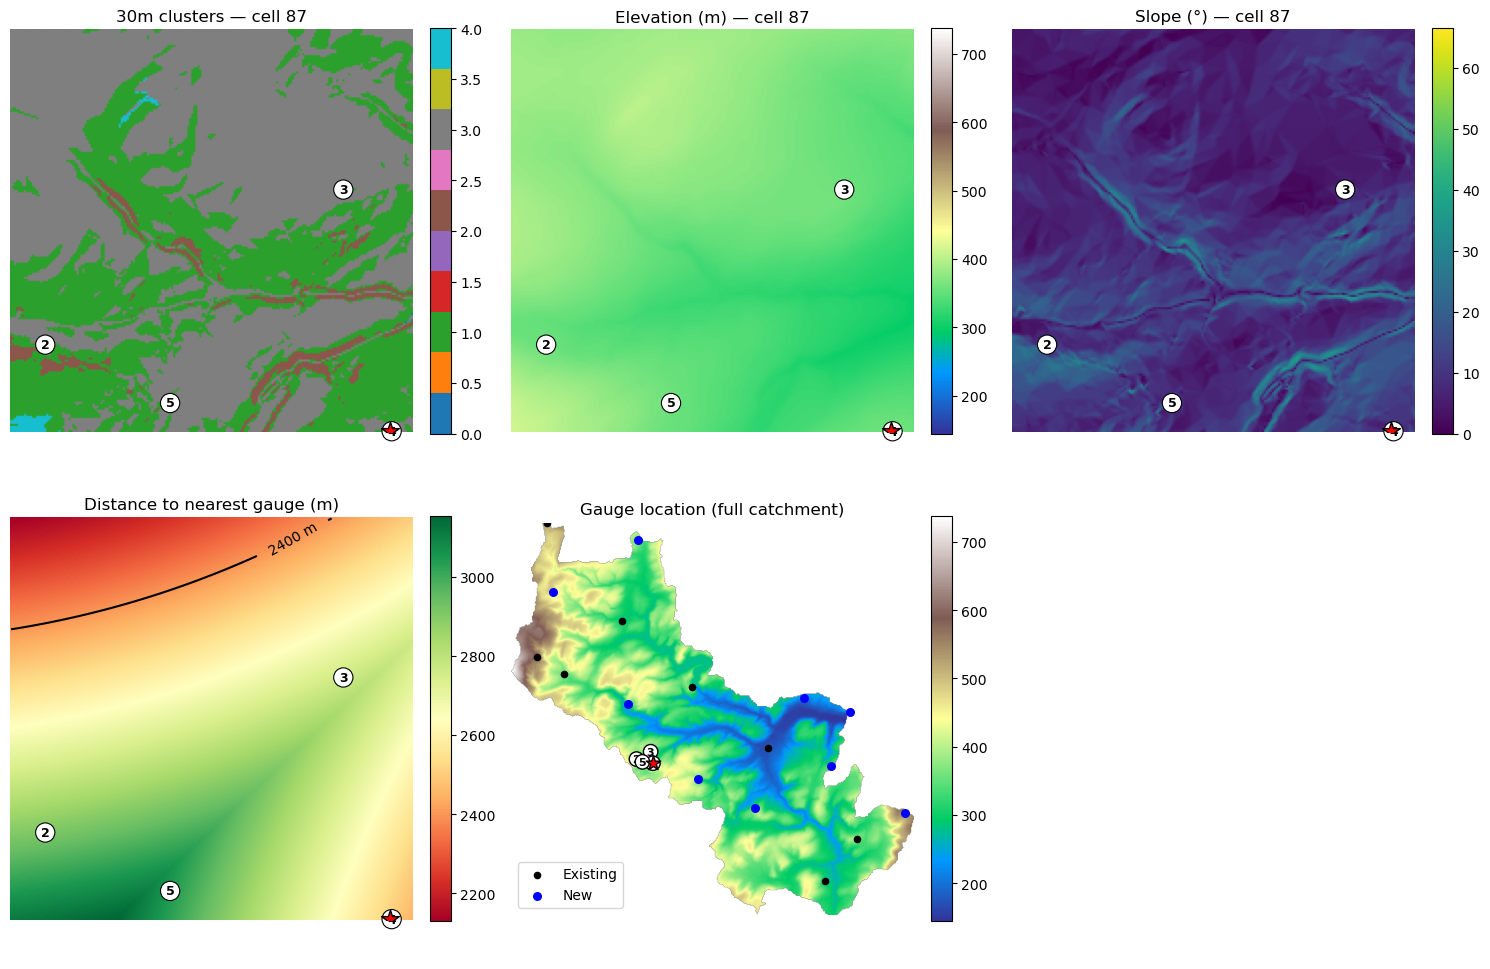

,new_gauge_num,rank,row,col,dem,slope,dist_to_target
0,4,1,2514,1483,357.820007,9.592897,0.001034
1,4,2,2471,1312,357.510010,9.594905,0.004490
2,4,3,2394,1460,357.459991,9.602956,0.005278
3,4,4,2514,1484,357.829987,9.537428,0.006800
4,4,5,2500,1374,357.209991,9.621172,0.008784


220


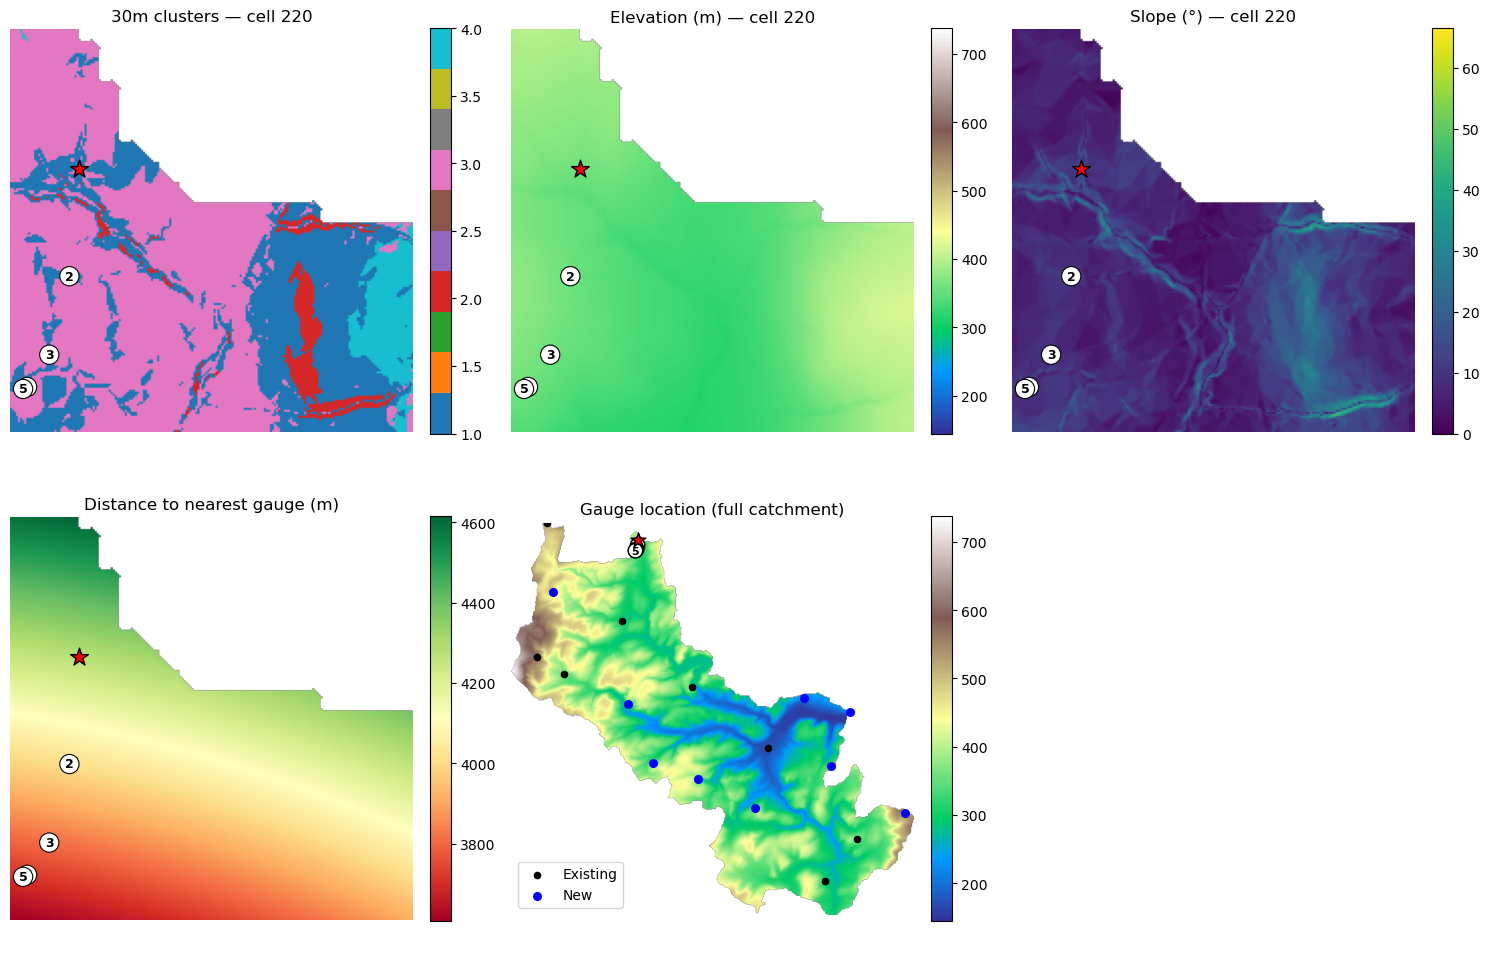

,new_gauge_num,rank,row,col,dem,slope,dist_to_target
0,5,1,184,1329,356.049988,9.473585,0.004482
1,5,2,237,1324,355.489990,9.500734,0.005250
2,5,3,276,1314,356.459991,9.496963,0.005872
3,5,4,292,1303,355.350006,9.548773,0.008594
4,5,5,293,1301,355.500000,9.579016,0.010505


52


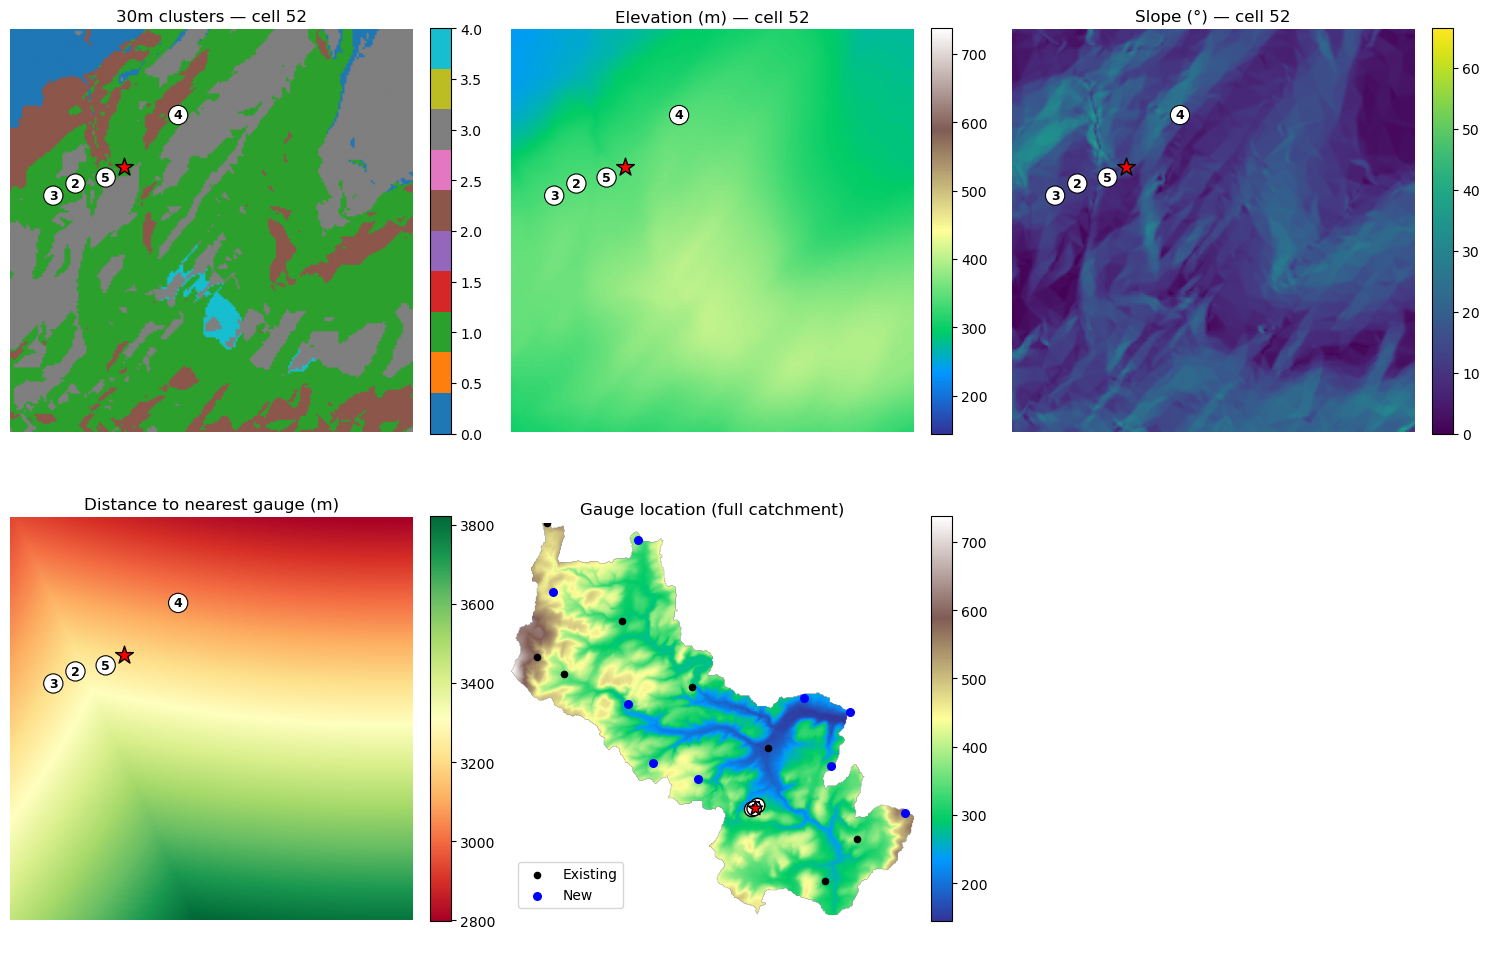

,new_gauge_num,rank,row,col,dem,slope,dist_to_target
0,6,1,2983,2551,340.299988,13.286215,0.002119
1,6,2,2991,2527,339.910004,13.359636,0.008627
2,6,3,2997,2516,340.940002,13.343883,0.008783
3,6,4,2957,2578,341.010010,13.341469,0.009251
4,6,5,2988,2542,340.940002,13.249864,0.009750


76


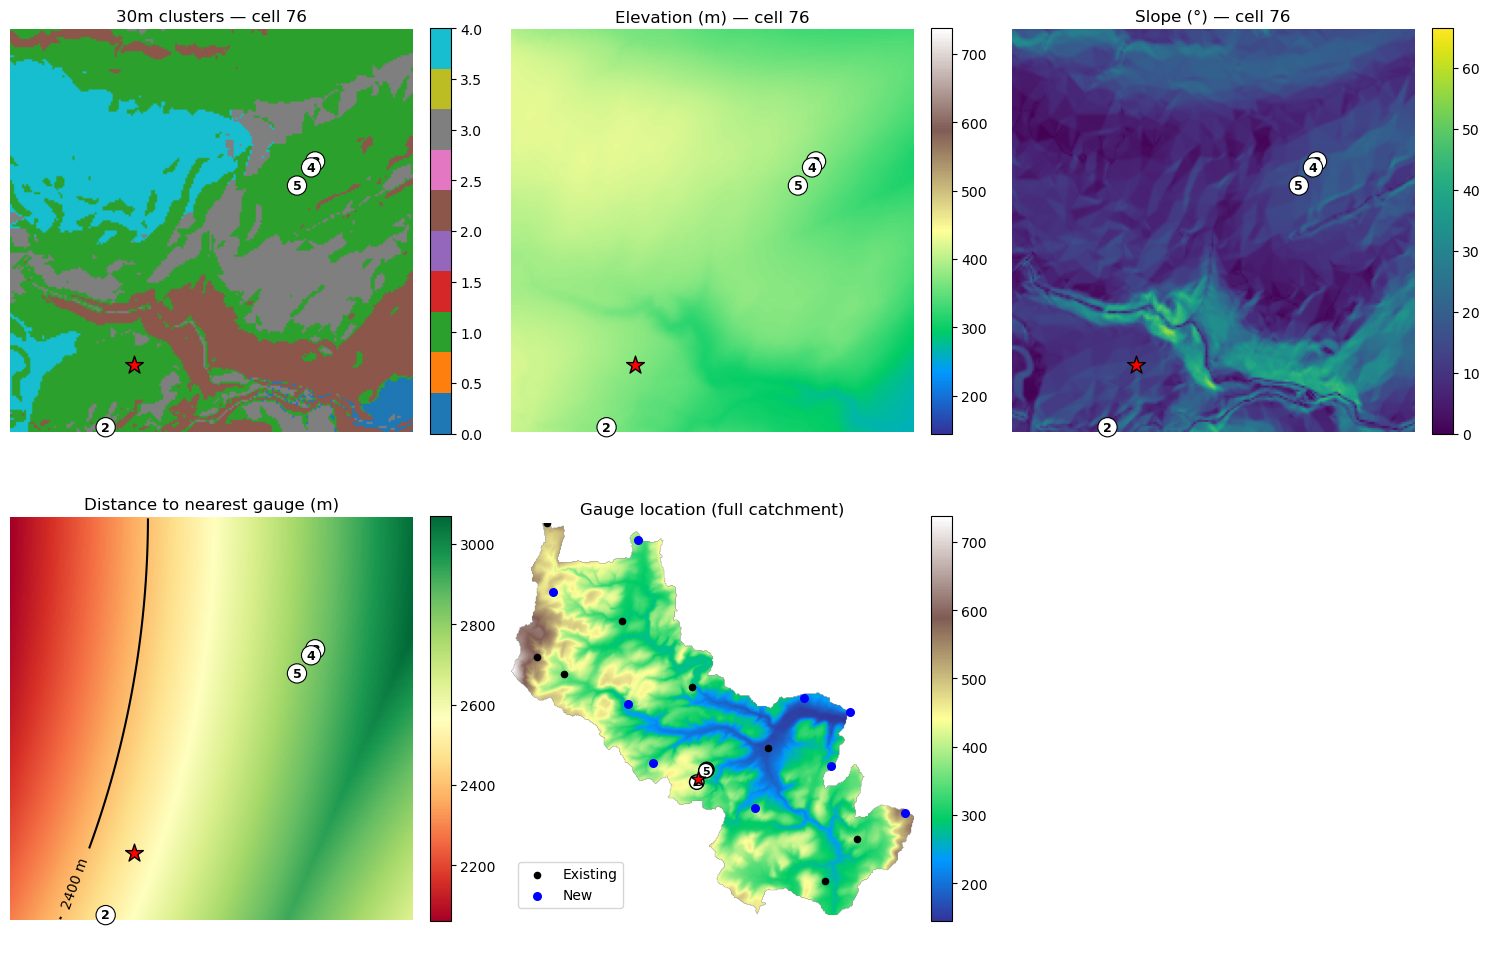

,new_gauge_num,rank,row,col,dem,slope,dist_to_target
0,7,1,2681,1956,371.100006,13.865969,0.005192
1,7,2,2712,1942,371.179993,13.930959,0.005618
2,7,3,2580,2046,371.390015,13.919375,0.006737
3,7,4,2583,2044,370.790009,13.954463,0.007122
4,7,5,2592,2037,371.029999,13.956064,0.007625


134


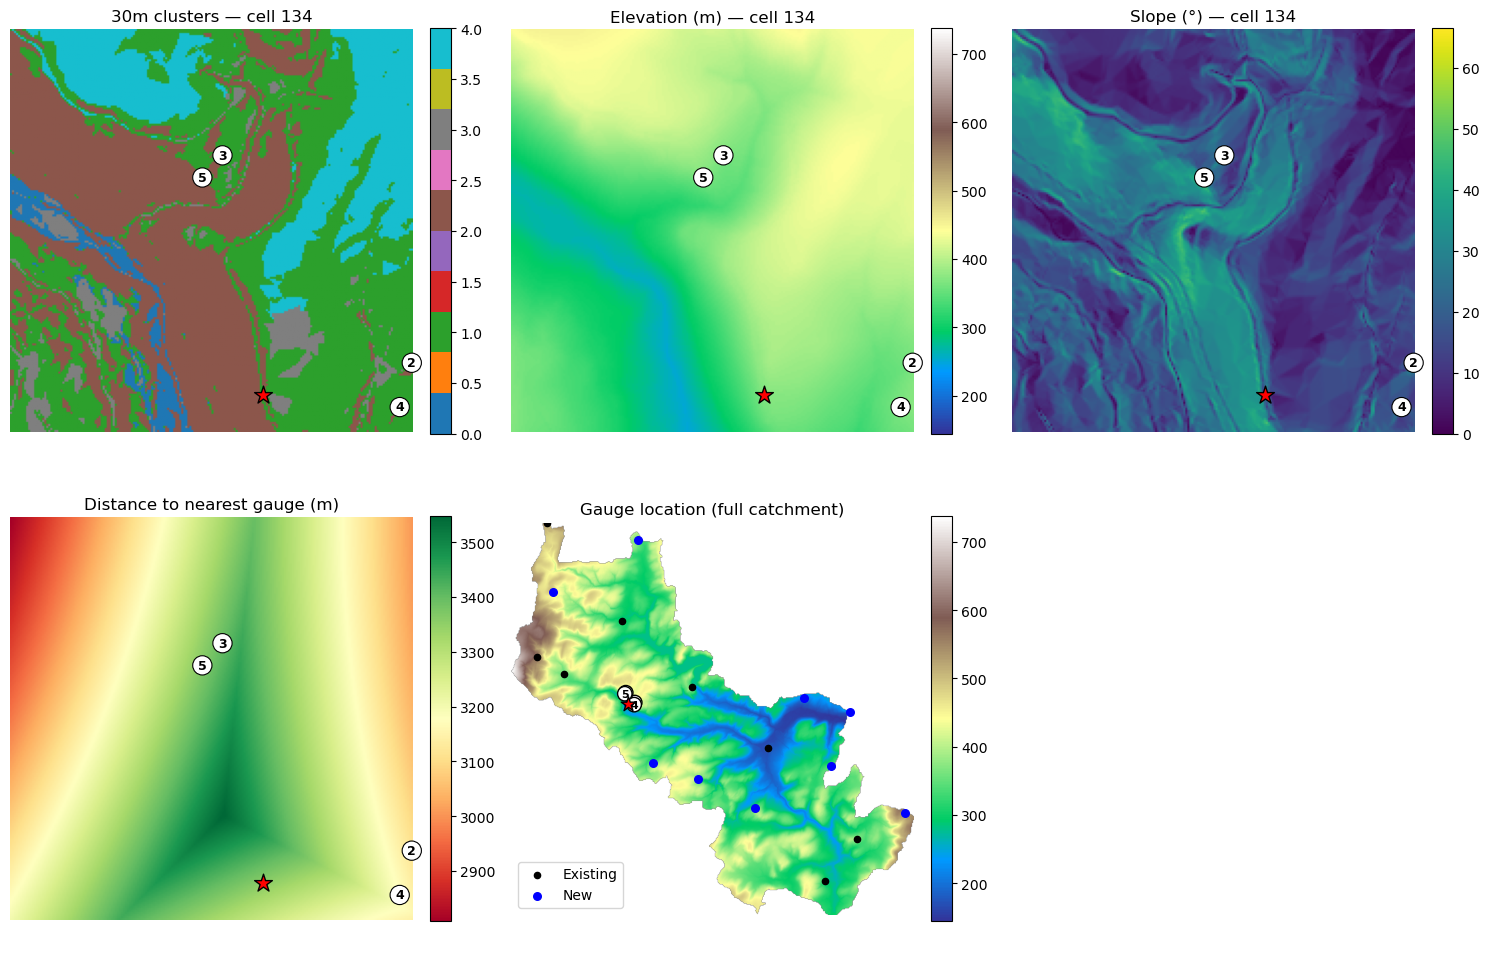

,new_gauge_num,rank,row,col,dem,slope,dist_to_target
0,8,1,1896,1220,366.179993,18.500641,0.008763
1,8,2,1880,1294,365.200012,18.634936,0.017009
2,8,3,1777,1200,367.010010,18.541876,0.018732
3,8,4,1902,1288,364.570007,18.660580,0.022209
4,8,5,1788,1190,365.410004,18.315682,0.024155


60


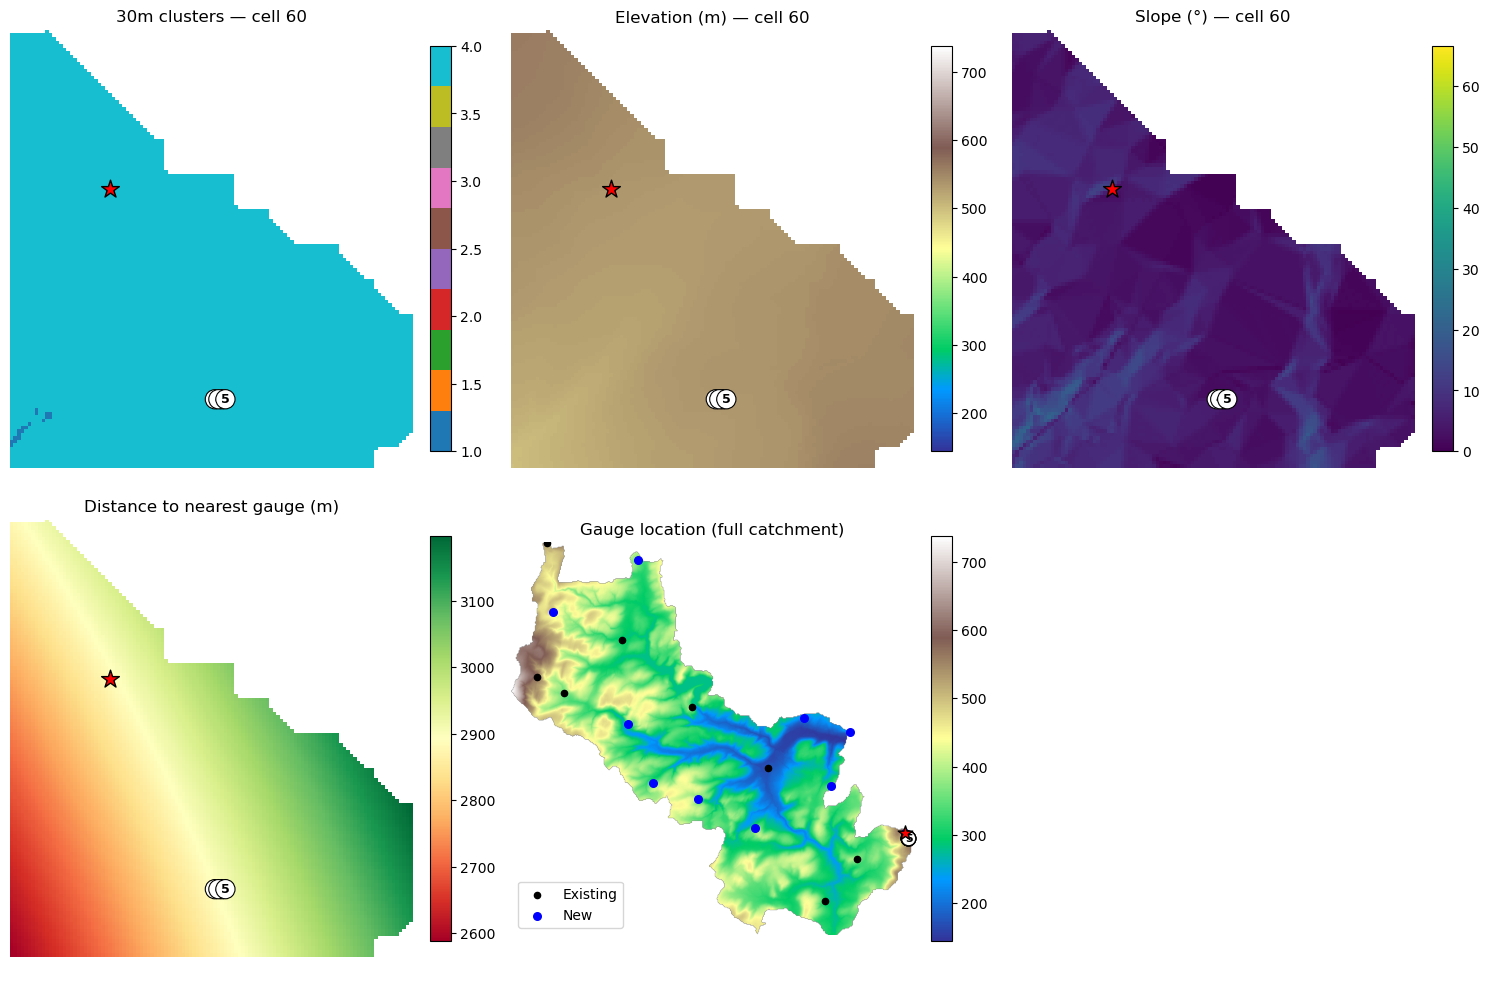

,new_gauge_num,rank,row,col,dem,slope,dist_to_target
0,9,1,3035,4123,535.700012,5.223186,0.003473
1,9,2,3095,4155,535.390015,5.211016,0.004487
2,9,3,3095,4153,535.440002,5.207585,0.004789
3,9,4,3095,4154,535.419983,5.207238,0.004873
4,9,5,3095,4156,535.359985,5.207585,0.005011


83


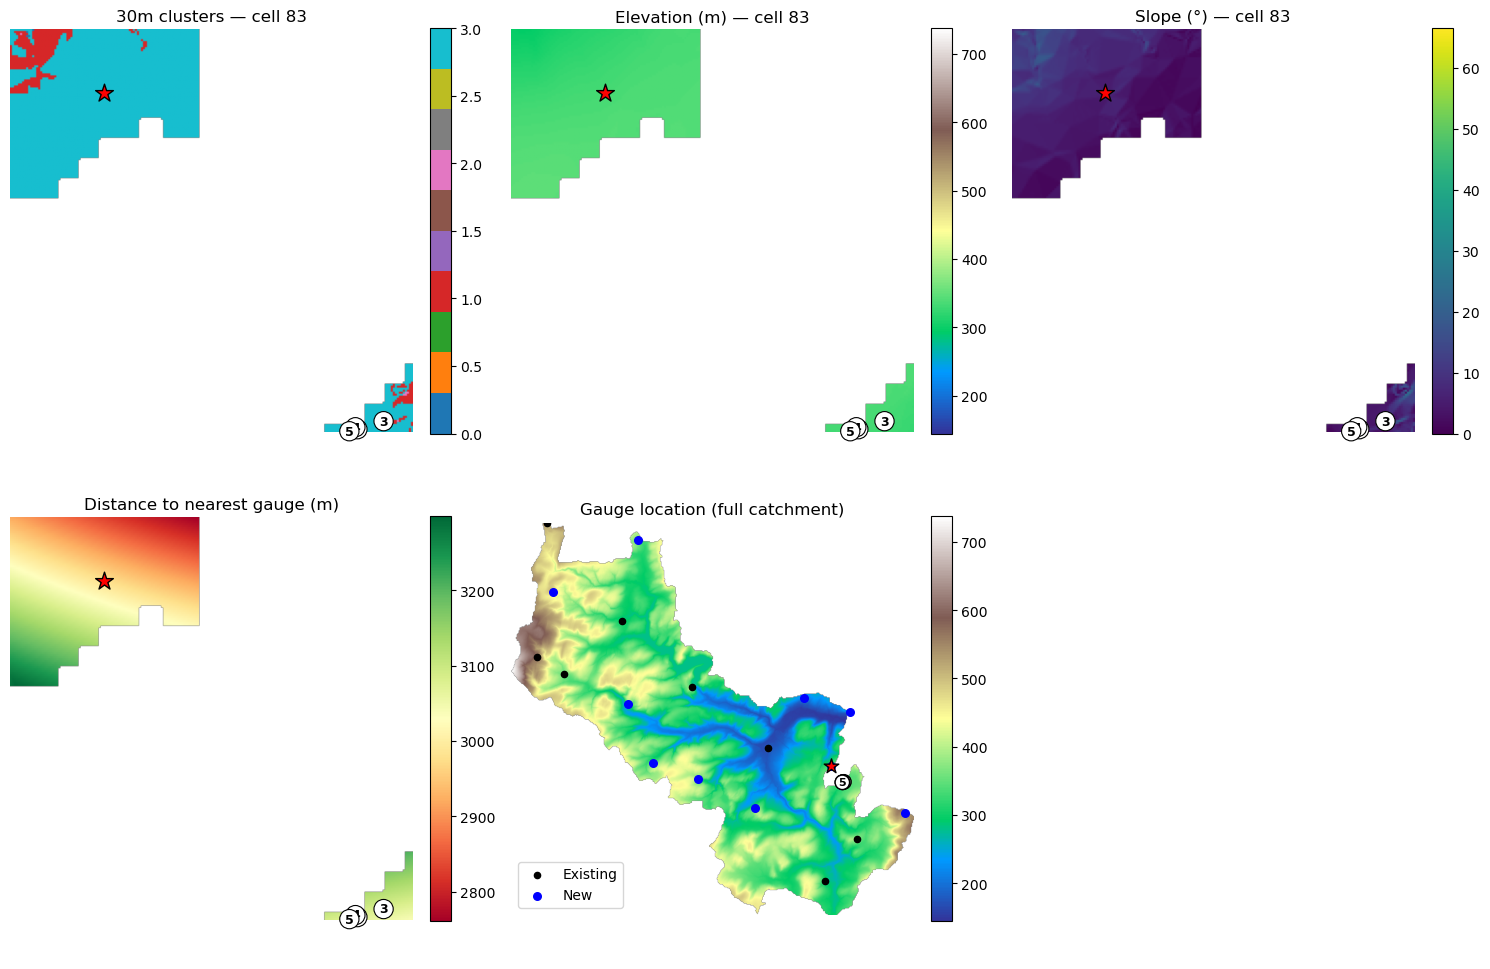

,new_gauge_num,rank,row,col,dem,slope,dist_to_target
0,10,1,2546,3341,333.160004,5.743332,0.003857
1,10,2,2713,3467,333.029999,5.748265,0.003866
2,10,3,2709,3480,332.809998,5.749560,0.004315
3,10,4,2712,3466,333.290009,5.738889,0.004494
4,10,5,2714,3463,332.480011,5.733519,0.005747


,new_gauge_num,rank,row,col,dem,slope,dist_to_target
0,1,1,1834,3062,214.479996,8.654608,0.002380
1,1,2,1834,3061,214.520004,8.657738,0.002603
2,1,3,1837,3075,213.929993,8.653424,0.004427
3,1,4,1834,3063,214.440002,8.702291,0.005070
4,1,5,1835,3062,213.720001,8.654523,0.006672
5,2,1,2002,3512,177.100006,10.692143,0.108763
6,2,2,2003,3514,176.919998,10.637896,0.112241
7,2,3,2004,3515,176.500000,10.762332,0.114143
8,2,4,2005,3516,176.080002,10.911273,0.118549
9,2,5,2004,3514,176.080002,10.613238,0.122167


In [55]:
import functions
importlib.reload(functions)
from functions import *   # expects: is_feasible, greedy_selection_multi (or greedy_selection), score

min_dist = 2400
all_ranked = []

for zone_id in selected_df['zone_id']:
    ranked = find_backup_30m_locations(selected_df, zone_raster, combined_mask, labels_30m_full, dem_arr, slope_arr,
                              valid_mask_30m, existing_coords, transform, diagnostics, min_dist, zone_id)
    
    subset = ranked[['new_gauge_num', 'rank', 'row', 'col','dem', 'slope', 'dist_to_target']].copy()
    
    display(subset)
    all_ranked.append(subset)

# 🔗 Combine everything into one dataframe
all_ranked_df = pd.concat(all_ranked, ignore_index=True)

# Optional: reset index nicely
all_ranked_df = all_ranked_df.reset_index(drop=True)

display(all_ranked_df)    

<div style="background-color: lightblue; border: 2px solid black; border-radius: 10px; padding: 30px 20px; margin: 10px 0px; text-align: center;">
    
<div style="text-align: left; margin-top: 20px;">
    
--- 
4. Plot results
---    
  

</div>

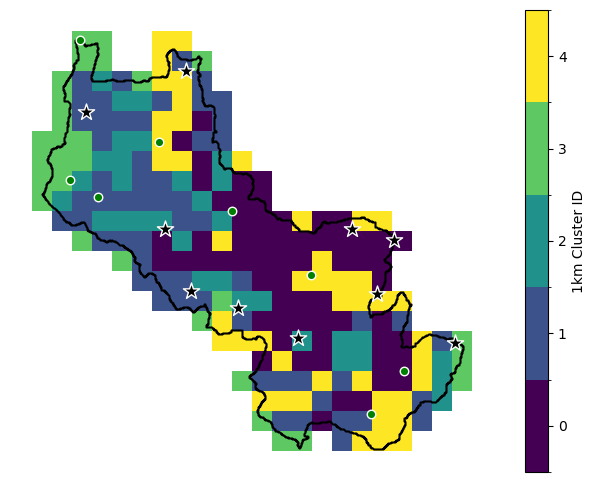

In [64]:
cmap = plt.get_cmap("viridis", 5)

fig, ax = plt.subplots(figsize=(8, 6))

rainfall_gdf_valid.plot(column="cluster", ax=ax, cmap=cmap, norm=norm, legend=False)
catchment_Dolwen.boundary.plot(ax=ax, color="black")

ax.scatter(selected_df["x"], selected_df["y"], c="black", edgecolor="white",
           s=150, marker="*", zorder=5, label="New sites")
gauge_with_cells.plot(ax=ax, color="green", marker=".", markersize=150,
                       edgecolor="white", zorder=5, label="Existing gauges")

# manually add the hatch pattern to the legend (hatch alone won't auto-appear)
hatch_patch = Patch(facecolor="none", edgecolor="black", hatch="///",
                     label=f"Below purity threshold ({purity_threshold})")

# Add legend
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []
cbar = plt.colorbar(sm, ax=ax, boundaries=bounds, ticks=range(5))
cbar.set_label("1km Cluster ID")

ax.axis('off');

<div style="background-color: lightblue; border: 2px solid black; border-radius: 10px; padding: 30px 20px; margin: 10px 0px; text-align: center;">
    
<div style="text-align: left; margin-top: 20px;">
    
--- 
4. Analyse results
---    
    

</div>

In [ ]:
# --------------------------------------------------
# 13. Distribution check — where do new + existing gauges fall
#     relative to the full catchment DEM/slope distributions
# --------------------------------------------------

# Get existing gauges' own 30m pixel dem/slope values
gauge_rows, gauge_cols = rasterio.transform.rowcol(
    transform, gauge_with_cells.geometry.x.values, gauge_with_cells.geometry.y.values)

gauge_rows = np.array(gauge_rows)
gauge_cols = np.array(gauge_cols)

gauge_dem = dem_arr[gauge_rows, gauge_cols]
gauge_slope = slope_arr[gauge_rows, gauge_cols]
gauge_clusters = gauge_with_cells["cluster"].values

fig, axs = plt.subplots(ncols=2, figsize=(12, 4))

# ---- Elevation ----
axs[0].hist(dem_arr[valid_mask_30m], bins=50, color="lightgray", edgecolor="black", zorder=1)

for _, row in selected_df.iterrows():
    axs[0].axvline(row["dem"], color=cmap(row["cluster"] / (k - 1)),
                    linewidth=3, linestyle="-", zorder=3)

for val, cluster in zip(gauge_dem, gauge_clusters):
    axs[0].axvline(val, color=cmap(cluster / (k - 1)), linewidth=3,
                    linestyle="--", alpha=0.8, zorder=2)

axs[0].set_xlabel("Elevation (m)")
axs[0].set_ylabel("Pixel count")
axs[0].set_title("Elevation distribution")

# ---- Slope ----
axs[1].hist(slope_arr[valid_mask_30m], bins=50, color="lightgray", edgecolor="black", zorder=1)

for _, row in selected_df.iterrows():
    axs[1].axvline(row["slope"], color=cmap(row["cluster"] / (k - 1)),
                    linewidth=3, linestyle="-", zorder=3)

for val, cluster in zip(gauge_slope, gauge_clusters):
    axs[1].axvline(val, color=cmap(cluster / (k - 1)), linewidth=3,
                    linestyle="--", alpha=0.8, zorder=2)

axs[1].set_xlabel("Slope (degrees)")
axs[1].set_ylabel("Pixel count")
axs[1].set_title("Slope distribution")

# ---- Legend ----
cluster_handles = [
    Line2D([0], [0], color=cmap(c / (k - 1)), lw=2, label=f"New — cluster {c}")
    for c in sorted(selected_df["cluster"].unique())]
existing_handle = Line2D([0], [0], color="black", lw=1, linestyle="--", alpha=0.6, label="Existing gauge")
fig.legend(handles=cluster_handles + [existing_handle],
           loc="upper center", ncol=min(len(cluster_handles) + 1, 7),
           bbox_to_anchor=(0.5, 1.12), fontsize=8)

plt.tight_layout()

In [ ]:
fig, axs = plt.subplots(ncols =2, figsize=(12, 4))
data_by_cluster = [rainfall_gdf_valid.loc[rainfall_gdf_valid["cluster"] == c, "mean_slope"].dropna()
                    for c in range(k)]
axs[0].boxplot(data_by_cluster, tick_labels=[f"Cluster {c}" for c in range(k)])
axs[0].set_title("Slope")

data_by_cluster = [rainfall_gdf_valid.loc[rainfall_gdf_valid["cluster"] == c, "mean_dem"].dropna()
                    for c in range(k)]
axs[1].boxplot(data_by_cluster, tick_labels=[f"Cluster {c}" for c in range(k)])
axs[1].set_title("Elevation");

In [ ]:
# best_purity_per_cluster = rainfall_gdf_valid.groupby("cluster")["purity"].max()
# cluster_pixel_counts = pd.Series(labels_30m_full[labels_30m_full >= 0]).value_counts().reindex(range(k_30m))

# fig, ax = plt.subplots(figsize=(5, 4))
# ax.scatter(cluster_pixel_counts.values, best_purity_per_cluster.reindex(range(k)).values, s=80)
# for c in range(k):
#     ax.annotate(str(c), (cluster_pixel_counts.get(c, 0), best_purity_per_cluster.get(c, np.nan)))
# ax.set_xlabel("30m cluster size (pixel count)")
# ax.set_ylabel("Best achievable purity (1km cell)")
# ax.set_title("Does cluster rarity explain low purity?")

In [ ]:
fig, axs = plt.subplots(ncols=2, figsize=(11, 4))

axs[0].scatter(rainfall_gdf_valid["mean_slope"], rainfall_gdf_valid["purity"], s=8, alpha=0.4)
axs[0].set_xlabel("1km cell mean slope (degrees)")
axs[0].set_ylabel("30m purity")
axs[0].set_title("Purity vs. slope")

axs[1].scatter(rainfall_gdf_valid["mean_dem"], rainfall_gdf_valid["purity"], s=8, alpha=0.4)
axs[1].set_xlabel("1km cell mean elevation (m)")
axs[1].set_ylabel("30m purity")
axs[1].set_title("Purity vs. elevation")

plt.tight_layout()

In [ ]:
high_purity_zones = rainfall_gdf_valid.loc[rainfall_gdf_valid["purity"] >= purity_threshold, "zone_id"]
high_purity_pixel_mask = combined_mask & np.isin(zone_raster, high_purity_zones)

fig, axs = plt.subplots(ncols=2, figsize=(12, 4))

axs[0].hist(dem_arr[valid_mask_30m], bins=50, density=True, alpha=0.4, label="All catchment pixels", color="gray")
axs[0].hist(dem_arr[high_purity_pixel_mask], bins=50, density=True, alpha=0.5, label="Pixels in high-purity cells only", color="steelblue")
axs[0].hist(selected_df["dem"], bins=20, density=True, alpha=0.6, label="Selected sites", color="orange")
axs[0].set_xlabel("Elevation (m)"); axs[0].legend(); axs[0].set_title("Elevation: candidate pool vs. selection")

axs[1].hist(slope_arr[valid_mask_30m], bins=50, density=True, alpha=0.4, label="All catchment pixels", color="gray")
axs[1].hist(slope_arr[high_purity_pixel_mask], bins=50, density=True, alpha=0.5, label="Pixels in high-purity cells only", color="steelblue")
axs[1].hist(selected_df["slope"], bins=20, density=True, alpha=0.6, label="Selected sites", color="orange")
axs[1].set_xlabel("Slope (degrees)"); axs[1].legend(); axs[1].set_title("Slope: candidate pool vs. selection")

plt.tight_layout()

In [ ]:
fig, axs = plt.subplots(ncols=2, figsize=(14, 6))

excluded_mask = combined_mask & ~high_purity_pixel_mask

extent = [transform.c, transform.c + transform.a * dem_arr.shape[1],
          transform.f + transform.e * dem_arr.shape[0], transform.f]

excluded_display = np.full(dem_arr.shape, np.nan)
excluded_display[excluded_mask] = 1

# ---- Slope background ----
slope_xr = dem.copy()
slope_display = np.where(valid_mask_30m, slope_arr, np.nan)
slope_xr.data = slope_display
slope_xr.plot(ax=axs[0], cmap="Greens", alpha=0.6, add_colorbar=True,
              cbar_kwargs={"label": "Slope (degrees)"})
axs[0].imshow(excluded_display, cmap=mcolors.ListedColormap(["red"]), alpha=0.5, extent=extent)
catchment_Dolwen.boundary.plot(ax=axs[0], color="black")
axs[0].axis("off")
axs[0].set_title("Red = excluded from candidate pool\n(overlaid on slope)")

# ---- Elevation background ----
dem_xr = dem.copy()
dem_display = np.where(valid_mask_30m, dem_arr, np.nan)
dem_xr.data = dem_display
dem_xr.plot(ax=axs[1], cmap="Blues", alpha=0.6, add_colorbar=True,
            cbar_kwargs={"label": "Elevation (m)"})
axs[1].imshow(excluded_display, cmap=mcolors.ListedColormap(["red"]), alpha=0.5, extent=extent)
catchment_Dolwen.boundary.plot(ax=axs[1], color="black")
axs[1].axis("off")
axs[1].set_title("Red = excluded from candidate pool\n(overlaid on elevation)")

plt.tight_layout()